Notebook for determining appropriate scenario weighting.

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import seaborn as sns

import sim_ranking as sr
import ml_tools as mlt

In [25]:
mpl.rcdefaults()  # Resets Matplotlib settings

# Disable FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Config
obs_data_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v4.0/Tables/ground_motion_im_table_rotd50_flat.csv")

In [4]:
# Load observed data
obs_data = sr.data.load_obs_nzgmdb(obs_data_ffp)

events, all_sites = obs_data.events, obs_data.sites
event_sites = obs_data.event_sites
print(f"Number of events: {len(events)}")

Number of events: 3149


In [5]:
# Get the set of valid site-interests per event
print(f"Getting valid sites of interest")
int_sites, valid_event_int_sites, _ = sr.ml.data.get_valid_site_ints(
    event_sites, obs_data.record_df.drop(columns=obs_data.ims)
)
events = np.intersect1d(events, np.asarray(list(valid_event_int_sites.keys())))

Getting valid sites of interest
Valid SOI records: 39033/46641


In [7]:
# Distance matrix
dist_matrix = sr.utils.calculate_distance_matrix(all_sites, obs_data.site_df)

Computing distance matrix


In [13]:
# Loth & Baker spatial correlations
corr_data = sr.LBSiteCorrelationData.from_dist_matrix(dist_matrix, sr.constants.PSA_KEYS)

In [8]:
# Compute available scenarios
obs_sites = all_sites

site_combs, event_sites = sr.ml.data.compute_site_combinations(
    event_sites,
    valid_event_int_sites,
    events,
    dist_matrix,
    obs_sites,
    int_sites,
    max_dist=20,
    max_n_obs_sites=10
)

In [15]:
# Create scenario dataframe
scenario_df = sr.ml.utils.create_scenario_df(site_combs, event_sites, obs_data, dist_matrix=dist_matrix, lb_corr_data=corr_data)
print(scenario_df.shape)

(27101, 9)


## Magnitude

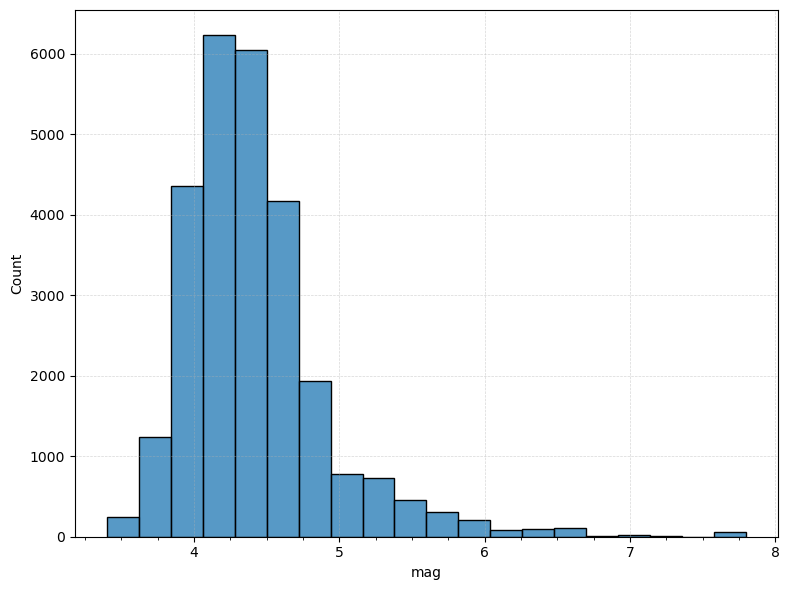

In [64]:
# Plot magnitude distribution
fig,  = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["mag"], bins=20, ax=)
.grid(linewidth=0.5, alpha=0.5, linestyle="--")
.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
.set_title("Magnitude Distribution (Original)")
fig.tight_layout()

Don't care about magnitudes < 4,and everything <= 4.8 has lots of data. So only need to increase the weighting from magnitude ~4.8

In [59]:
def weight_func(mag_values: np.ndarray[float]):
    weights = np.ones_like(mag_values)
    weights[mag_values > 6] = 5

    grad = -(5 - 1) / (6.0 - 4.8)
    bias = -grad * 6
    weights = np.where((mag_values > 4.8) & (mag_values <= 6), 5 - (grad*mag_values + bias), weights)

    return weights

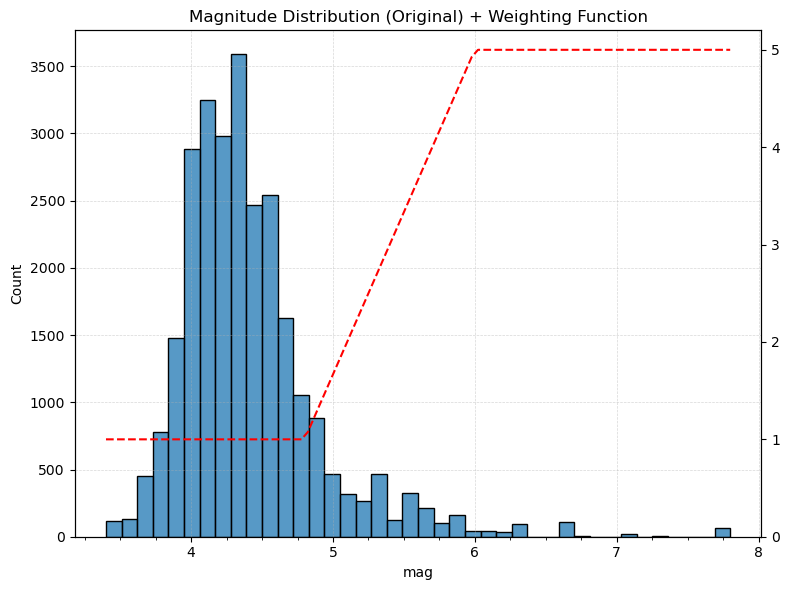

In [65]:
# Plot magnitude distribution
fig,  = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["mag"], bins=40, ax=)
.grid(linewidth=0.5, alpha=0.5, linestyle="--")
.xaxis.set_minor_locator(plt.MultipleLocator(0.25))

# Weighting
mag_values = np.linspace(scenario_df.mag.min(), scenario_df.mag.max(), 100)
weights = weight_func(mag_values)
ax_weight = .twinx()
ax_weight.plot(mag_values, weights, color="red", linestyle="--")
ax_weight.set_ylim(0.0, None)

.set_title("Magnitude Distribution (Original) + Weighting Function")

fig.tight_layout()

In [61]:
scenario_df["mag_weight"] = weight_func(scenario_df["mag"])

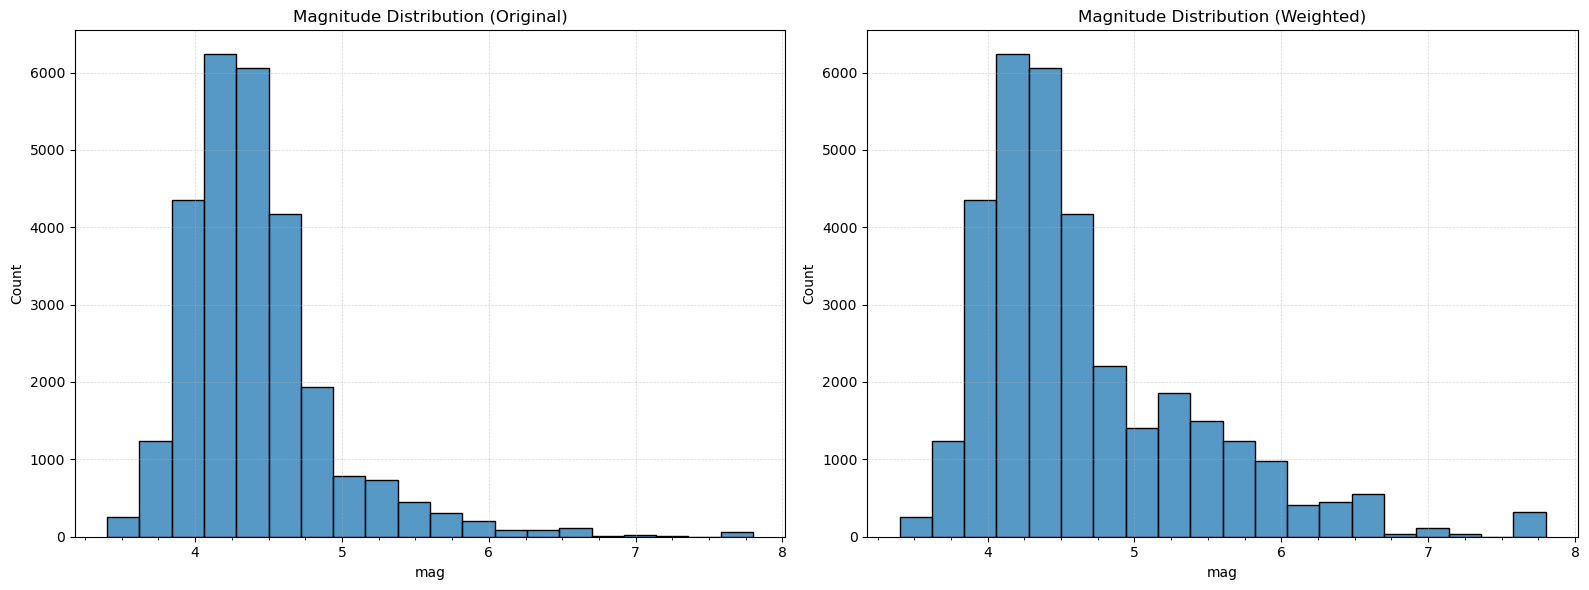

In [68]:
# Plot magnitude distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(data=scenario_df, x="mag", bins=20, ax=ax1)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax1.set_title("Magnitude Distribution (Original)")


sns.histplot(data=scenario_df, x="mag", bins=20, ax=ax2, weights="mag_weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.25))

ax2.set_title("Magnitude Distribution (Weighted)")

fig.tight_layout()

## $R_{Rup}$

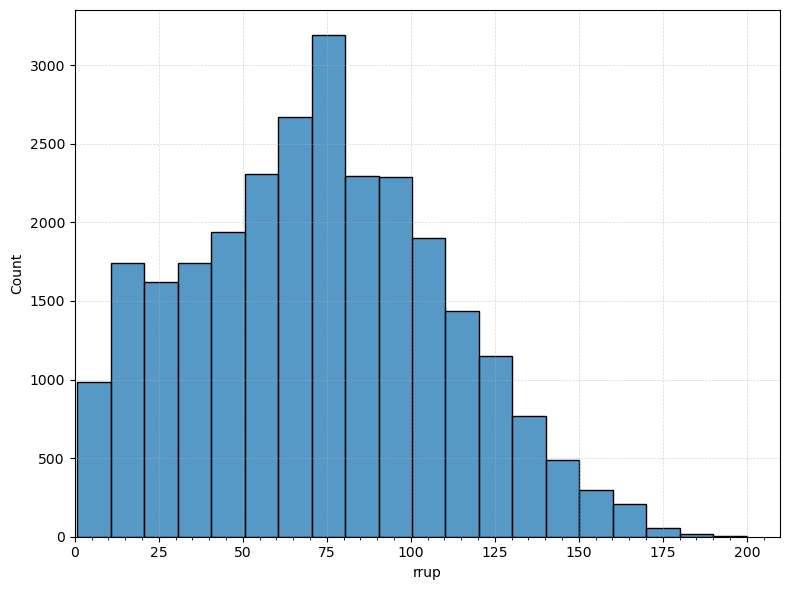

In [71]:
# Plot distance distribution
fig, ax_hist = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["rrup"], bins=20, ax=ax_hist)
ax_hist.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax_hist.xaxis.set_minor_locator(plt.MultipleLocator(5))
ax_hist.set_xlim(0.0)
fig.tight_layout()

Don't think $R_{Rup}$ needs to be weighted.

## Degree of Constraint

In [72]:
scenario_df

,event,site_int,obs_sites,n_obs_sites,rrup,mag,obs_distances,min_obs_distance,constraintness,mag_weight
1502698_MISS,1502698,MISS,"[RQGS, TFSS, PGMS]",3,63.892520,5.200,"[3.727524995803833, 5.296543598175049, 11.2819...",3.727525,1.198230,2.333333
1502698_PGMS,1502698,PGMS,"[TFSS, MISS, RQGS]",3,56.230804,5.200,"[9.859759330749512, 11.281909942626953, 11.485...",9.859759,0.871265,2.333333
1502698_RQGS,1502698,RQGS,"[TFSS, MISS, PGMS]",3,65.595720,5.200,"[2.35406756401062, 3.727524995803833, 11.48556...",2.354068,1.309620,2.333333
1502698_TFSS,1502698,TFSS,"[RQGS, MISS, PGMS]",3,64.621340,5.200,"[2.35406756401062, 5.296543598175049, 9.859759...",2.354068,1.284166,2.333333
1504146_MISS,1504146,MISS,"[RQGS, TFSS, WEMS, POTS, PGMS]",5,62.113815,5.418,"[3.727524995803833, 5.296543598175049, 5.58199...",3.727525,2.025832,3.060000
...,...,...,...,...,...,...,...,...,...,...
3792057_CACS,3792057,CACS,"[CMHS, SWNC]",2,26.404085,3.800,"[11.91573715209961, 12.968032836914062]",11.915737,0.525613,1.000000
3792057_CMHS,3792057,CMHS,[CACS],1,30.490385,3.800,[11.91573715209961],11.915737,0.271363,1.000000
3792057_DFHS,3792057,DFHS,[OXZ],1,19.100065,3.800,[18.948415756225586],18.948416,0.180979,1.000000
3792057_OXZ,3792057,OXZ,[DFHS],1,36.115788,3.800,[18.948415756225586],18.948416,0.180979,1.000000


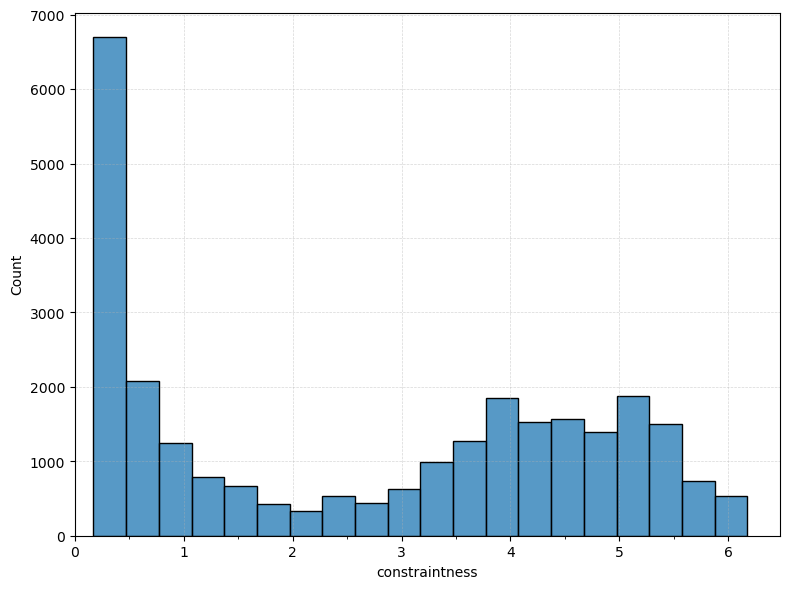

In [73]:
# Plot degree of constraint distribution
fig, ax_hist = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["constraintness"], bins=20, ax=ax_hist)
ax_hist.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax_hist.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax_hist.set_xlim(0.0)

ax_hist.set_title("Degree of Constraint Distribution (Original)")

fig.tight_layout()

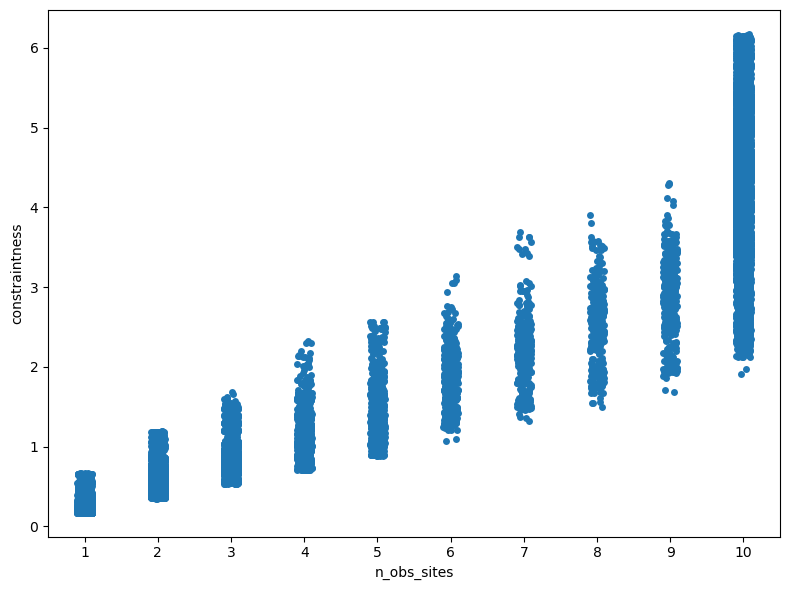

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.stripplot(data=scenario_df, x="n_obs_sites", y="constraintness", ax=ax)
fig.tight_layout()

In [93]:
def doc_weight_fn(doc: np.ndarray[float], max_weight: float = 2, min_weight: float = 1, linear_doc_start: float = 1, linear_doc_end: float = 6):
    weights = np.ones_like(doc)

    grad = (max_weight - min_weight) / (linear_doc_end - linear_doc_start)
    bias = max_weight - (grad * linear_doc_end)

    weights = np.where(doc > 1, doc * grad + bias, weights)
    return weights

In [94]:
scenario_df["doc_weight"] = doc_weight_fn(scenario_df["n_obs_sites"])

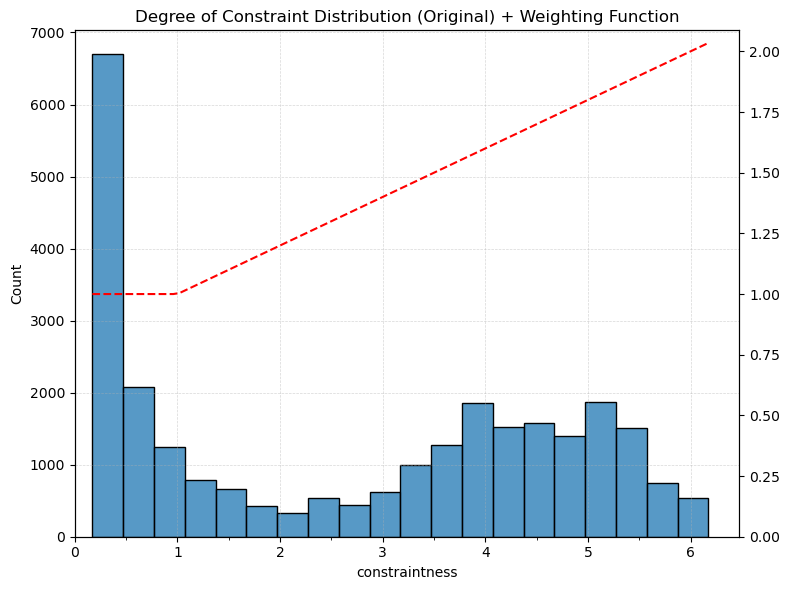

In [95]:
# Plot degree of constraint distribution
fig, ax_hist = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["constraintness"], bins=20, ax=ax_hist)
ax_hist.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax_hist.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax_hist.set_xlim(0.0)

# Weighting
doc_values = np.linspace(scenario_df.constraintness.min(), scenario_df.constraintness.max(), 100)
weights = doc_weight_fn(doc_values)

ax_weight = ax_hist.twinx()
ax_weight.plot(doc_values, weights, color="red", linestyle="--")
ax_weight.set_ylim(0.0, None)

ax_hist.set_title("Degree of Constraint Distribution (Original) + Weighting Function")

fig.tight_layout()

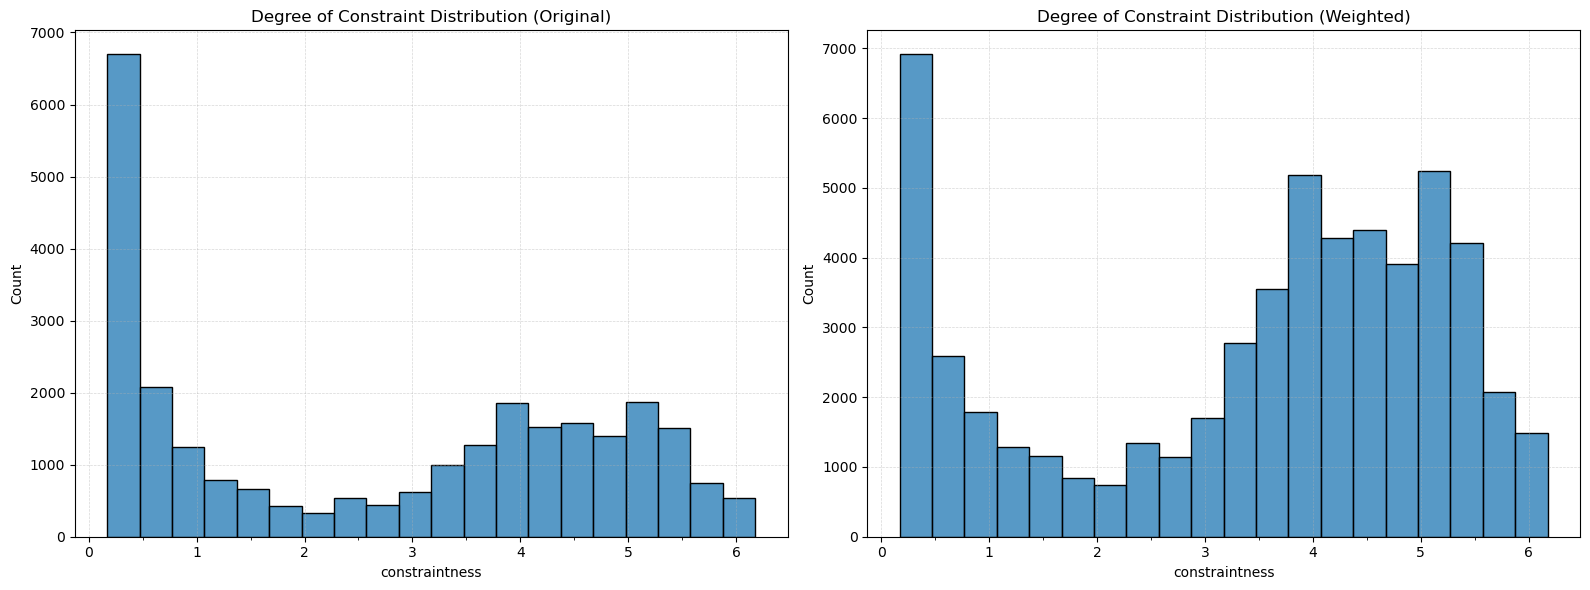

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=scenario_df, x="constraintness", bins=20, ax=ax1)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax1.set_title("Degree of Constraint Distribution (Original)")

sns.histplot(data=scenario_df, x="constraintness", bins=20, ax=ax2, weights="doc_weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax2.set_title("Degree of Constraint Distribution (Weighted)")

fig.tight_layout()
